For linear regression, we have
$$h_\theta(x) = \theta_0+\theta_1x_1+...+\theta_dx_d = \theta^T\mathbf{x}$$
If we have $n$ data samples $(x^1, y^1),..., (x^n, y^n)$, the loss function is given by
$$L(\theta)=\frac{1}{2}\sum_{i=1}^n(h_\theta(x^i)-y^i)^2$$
This is also called the **least square** fitting.

## Gradient Descent
For $k=0,...,$ {

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; $\theta_j^{k+1}:=\theta^k_j -\alpha\frac{\partial L}{\partial \theta^k_j}$

}
- Goal: choose $\theta$ so as to minimize $L(\theta)$.
- A search algorithm that starts with some "initial guess" for $\theta^0$
- Repeatedly change $\theta$ to make $L(\theta)$ smaller, until hopefully it converges to a $\theta$ that minimiezes $L(\theta)$, $\|\theta^{k+1}-\theta^{k}\|\leq tol(10^{-5})$.
- This update is simultanenously performed for all parameter values $j=0,1,...,d$.
- $\alpha$ is called the learning rate.
- Repeatedly takes a step in the direction of **steepest decrease of $L$**.
## Simplify the gradient of loss function

\begin{align}
\frac{\partial L}{\partial \theta_j} &= \frac{\partial}{\partial \theta_j}(\frac{1}{2}(h_\theta(x)-y)^2) \\
&=2\cdot\frac{1}{2}(h_\theta(x)-y)\cdot\frac{\partial}{\partial\theta_j}(h_\theta(x)-y)\\
&=(h_\theta(x)-y)\cdot\frac{\partial}{\partial\theta_j}(\sum_{i=0}^d\theta_ix_i-y)\\
&=(h_\theta(x)-y)x_j
\end{align}
For each single training data point, this gives the update rule:
$$\theta_j: = \theta_j + \alpha(y^i-h_\theta(x^i))x_j^i$$
- This rule is called the **least mean squares (LMS)**
- The magnitude of the parameters ($\theta$) update is proportional to the **error term ($y^i-h_\theta(x^i)$)**.
- For a training data point $x^i$, if our prediction nearly matches the actualy value of $y^i$, the error is small. There is littel nee to change the paramters.
- In contrast, a larger change to the parameters will be made if our prediction ($h_\theta(x^i)$) is bad (i.e., has a large error ($y^i-h_\theta(x^i)$))

## LMS for more than one training data
$$\theta_j: = \theta_j + \alpha\sum_{i=1}^n(y^i-h_\theta(x^i))x_j^i, \,\,\text{for every\,} j=0,1,..,d$$
By grouping the updates of the coordinates into an update of the vector $\theta=(\theta_0,\theta_1,...,\theta_d)^T$, we have
$$\theta: = \theta + \alpha\sum_{i=1}^n(y^i-h_\theta(x^i))x^i$$
- This method compute the loss at every data point (the entire training dataset) on every step, and is called **batch gradient descent (BGD)**
- Gradient descent can be susceptible to local minima in general
- For linear regression (least-square fitting), it has only one global optima. GD always converges to the global minimum.
- Loss function $L$ is a convex quadratic function.

## stochastic gradient descent
for $i=1$ to $n$, {

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; $\theta_j: = \theta_j + \alpha(y^i-h_\theta(x^i))x_j^i, \,\,\text{for every\,} j=0,1,..,d$

}
Grouping the parameters into the vector,

for $i=1$ to $n$, {

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; $\theta: = \theta + \alpha(y^i-h_\theta(x^i))x^i$

}
- Each time we update the parameters according to the gradient of the error with respect to **only one single training data**
- This algorithm is called **Stochastic Gradient Descent (SGD)**
- The BGD has to scan through the entire training set before taking an update of the parameters. Computationally expensive if $n$ is large. (think about if you have 1 million dataset)
- SGD can start making progress right away, and continues to make progress with each example it looks at.
- SGD gets $\theta$ "close" to the minimum much faster than BGD. However, it may never converge to the minimum, and the paramters $\theta$ will keep oscillating around the minimum of $L(\theta)$. But in practice, most of the values near the minimum will be reasonably good approximations to the true minimum.
- For these reasons, particularly when the training dataset is large, SGD is often preferred over BGD.

## The normal equation

### Matrix derivative

For a function $f: \mathbb{R}^{n\times d}\rightarrow \mathbb{R}$ mapping from matrices ($A$) to the real numbers, the derivative of $f$ with respect to $A$ to be:
$$\nabla f(A) = \begin{bmatrix}
\frac{\partial f}{\partial A_{11}} & \cdots & \frac{\partial f}{\partial A_{1d}} \\
\vdots & \ddots & \vdots \\
\frac{\partial f}{\partial A_{n1}}& \cdots & \frac{\partial f}{\partial A_{n1}}
\end{bmatrix}
$$
The gradient is an $n\times d$ matrix, with $(i,j)-$ element is $\partial f/\partial A_{ij}$. 

For example, $A=\begin{bmatrix} A_{11} & A_{12} \\
A_{21} & A_{22}
\end{bmatrix}$.
The function $f$ is given by $f(A) = \frac{3}{2}A_{11} + 5A^2_{12} + A_{21}A_{22}$. We have
$$\nabla f(A)=\begin{bmatrix} \frac{3}{2} & 10A_{12} \\
A_{22} & A_{21}\end{bmatrix}
$$

## Closed-form of the value $\theta$ for Linear Regression
Given a training dataset, define the **design matrix** $X$ to be $n\times (d+1)$ (including the constant $\theta_0$).
$$X=\begin{bmatrix}
- x^1 - \\
- x^2 - \\
  \vdots \\
- x^n -
\end{bmatrix}$$
$\vec{y}$ is the $n$ dimensional target value for the training dataset:
$$\vec{y}=\begin{bmatrix}
y^1\\
y^2\\
\vdots \\
y^n
\end{bmatrix}$$
We know the approximation function $h_\theta(x^i)=(x^i)^T\theta$. We can verify that,
\begin{align}
X\theta - \vec{y}&=\begin{bmatrix}
(x^1)^T\theta\\
\vdots \\
(x^n)^T\theta
\end{bmatrix}-\begin{bmatrix}
y^1\\
\vdots\\
y^n
\end{bmatrix}\\
& = \begin{bmatrix}
h_\theta(x^1)-y^1\\
\vdots\\
h_\theta(x^n) - y^n
\end{bmatrix}
\end{align}
Recall that for a vector $z$,  $z^Tz=\sum_{i=1}^nz_i^2$:
$$L(\theta)=\frac{1}{2}\sum_{i=1}^n(h_\theta(x^i)-y^i)^2 = \frac{1}{2}(X\theta-\vec{y})^T(X\theta -\vec{y})$$
To minimize $L$, let's find the gradient of $L$ with respect to $\theta$.
\begin{align}
\nabla L(\theta) &= \nabla \frac{1}{2}(X\theta-\vec{y})^T(X\theta-\vec{y})\\
&=\frac{1}{2}\nabla[(X\theta)^TX\theta-(X\theta)^T\vec{y}-\vec{y}^TX\theta+\vec{y}^T\vec{y}]\\
&= \frac{1}{2}\nabla[\theta^T(X^TX)\theta - \vec{y}^T(X\theta)-\vec{y}^T(X\theta)]\\
&=\frac{1}{2}\nabla[\theta^T(X^TX)\theta - 2(X^T\vec{y})^T\theta]\\
&=\frac{1}{2}(2X^TX\theta - 2X^T\vec{y})\\
&= X^TX\theta - X^T\vec{y}
\end{align}
- In the third step, we used the fact that $a^Tb=b^Ta$
- In the fifth step, we used the facts $\nabla b^Tx=b$ and $\nabla x^TAx = 2Ax$ for symmetric matrix $A$.
- To minimize $L$, we set the derivatives to zero, and obtain the **normal equation**:
$$X^TX\theta = X^T\vec{y}$$
- The optimal value of $\theta$ that minimizes the loss function is given in closed-from by equation
  $$\theta = (X^TX)^{-1}X^T\vec{y}$$

# Regularization in Linear Regression

Linear regression is a statistical method to model the relationship between a dependent variable \( y \) and one or more independent variables \( X \). However, when there are many features, the model can become too complex and overfit the training data. Regularization is a technique used to prevent overfitting by adding a penalty term to the loss function.

## Regularized Linear Regression

The linear regression model can be defined as:

$$
y = X \theta + \epsilon
$$

where:
- $y$ is the vector of observed values.
- $X$ is the matrix of input features.
- $\theta$ is the vector of coefficients to be estimated.
- $\epsilon$ is the error term.

The goal is to find $\beta$ that minimizes the following cost function:

$$
\text{Cost}L(\theta) = \frac{1}{2} \sum_{i=1}^{n} (y^{(i)} - \theta^TX^{(i)})^2
$$

where $n$ is the number of training examples.

### L2 Regularization (Ridge Regression)

In L2 regularization, also known as Ridge Regression, we add a penalty equal to the sum of the squared coefficients to the cost function:
$$
L(\theta) = \frac{1}{2} \sum_{i=1}^{n} (y^{(i)} - \theta^TX{(i)})^2 + \lambda \sum_{j=1}^{d} \theta_j^2
$$

where:
- $\lambda$ is the regularization parameter that controls the amount of shrinkage.
- $\sum_{j=1}^{n} \beta_j^2$ is the L2 norm of the coefficient vector $\beta$.

The regularization parameter $\lambda$ controls the trade-off between minimizing the error and minimizing the magnitude of the coefficients. As $\lambda$ increases, the coefficients $\beta$ are pushed towards zero, resulting in a simpler model.

### L1 Regularization (Lasso Regression)

In L1 regularization, also known as Lasso Regression, we add a penalty equal to the sum of the absolute values of the coefficients:

$$
L(\theta) = \frac{1}{2} \sum_{i=1}^{n} (y^{(i)} - \theta^TX^{(i)})^2 + \lambda \sum_{j=1}^{d} |\theta_j|
$$

The L1 penalty can set some coefficients exactly to zero, thus performing feature selection.

### Elastic Net

Elastic Net combines both L1 and L2 regularization:
$$
\text{Cost}(\theta) = \frac{1}{2} \sum_{i=1}^{n} (y^{(i)} - X^{(i)}\theta)^2 + \lambda_1 \sum_{j=1}^{d} |\theta_j| + \lambda_2 \sum_{j=1}^{n} \theta_j^2
$$

where $\lambda_1$ and $\lambda_2$ are regularization parameters.


### plot the function 
$$f(x,y) = 1.5-1.6e^{-0.05(3x^2+(y+3)^2)}$$
$$f_2(x,y) = f(x,y) + (0.5-e^{-0.1(3(x-3)^2) + (y-3)^2})$$
$$f_0(x,y) = 1.5-e^{-0.03(3x^2+y^2)}$$

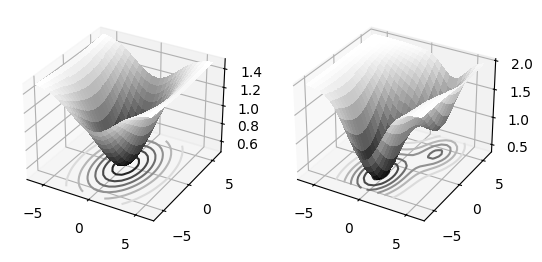

In [18]:
import numpy as np
import matplotlib.pyplot as plt

h = 0.5
x = np.arange(-6,6+h,h)
y = np.arange(-6,6+h,h)

X,Y = np.meshgrid(x,y)

F0 = 1.5 - 1.0*np.exp(-0.03*(3*np.power(X,2)+np.power(Y,2)))
F = 1.5 - 1.6*np.exp(-0.05*(3*np.power(X,2)+np.power(Y+3,2)))
F2 = F + (0.5 - 1.0*np.exp(-0.1*(3*np.power(X-3,2)+np.power(Y-3,2))))

# dF0x,dF0y = np.gradient(F0,h,h) 
# dF2x,dF2y = np.gradient(F2,h,h) 

#dF0y,dF0x = np.gradient(F0,h,h) 
#dF2y,dF2x = np.gradient(F2,h,h) 

#rcParams['figure.figsize'] = [16, 8]
fig,axs = plt.subplots(1,2,subplot_kw={'projection': '3d'})
axs[0].plot_surface(X, Y, F0, cmap='gray',linewidth=0, antialiased=False)
axs[0].contour(X, Y, F0, zdir='z', offset=axs[0].get_zlim()[0], cmap='gray')

axs[1].plot_surface(X, Y, F2, cmap='gray',linewidth=0, antialiased=False)
axs[1].contour(X, Y, F2, zdir='z', offset=axs[0].get_zlim()[0], cmap='gray')

## Use GD to optimize the function $f(x,y)=x^2+3y^2$

In [19]:
def f(x):
    # x is a 2d-vector contains x (x[0]), y (x[1])
    return x[0]**2 + 3*x[1]**2

In [20]:
# definie another function to compute the gradient of f(x,y)
def grad_f(x):
    dfdx = 2*x[0]
    dfdy = 6*x[1]
    grad = np.array([dfdx, dfdy])
    return grad

In [29]:
#gradient descent method for the 2D function.
def gradient_descent_2d(grad_f, x0, learning_rate, tol, max_iters):
    #initialize x as a vector [x0, y0]
    x = np.array(x0)
    #store the error for each step
    error_history = []
    for i in range(max_iters):
        #compute the gradient for current x
        grad_value = grad_f(x)

        #Key step: update x
        x_new = x - learning_rate * grad_value

        #check the convergence
        error = np.linalg.norm(x_new - x)
        error_history.append(error)
        if error < tol:
            print(f"converged in {i+1} iterations.")
            break
            
        x = x_new

    return x, np.array(error_history)
    

In [32]:
# parameters for GD
learning_rate = 0.1
initial_x = [2, 2] #initial x, y
tol = 1e-5 # 10^(-5)
max_iters = 50000

#perform the GD on f
optimal_x, error_history = gradient_descent_2d(grad_f, initial_x,learning_rate, tol, max_iters)

print(f"Optimal x: {optimal_x}")
print(f"Optimal f(x): {f(optimal_x)}")

converged in 49 iterations.
Optimal x: [4.46014904e-05 1.58456325e-19]
Optimal f(x): 1.9892929456391476e-09


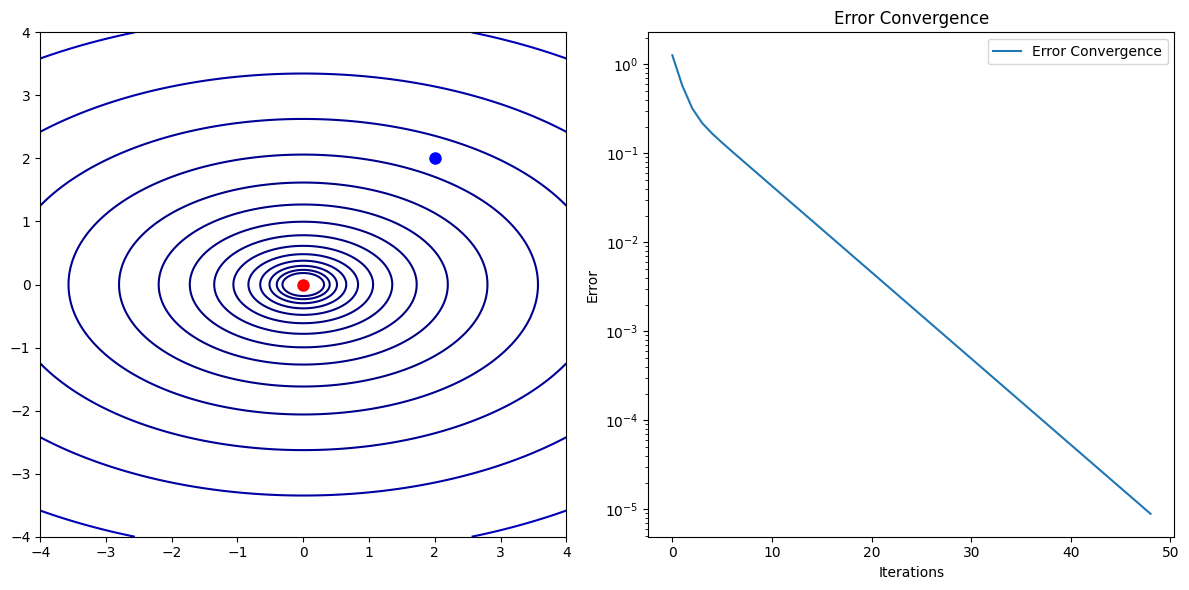

In [33]:
#plotting the function
x_vals = np.linspace(-4, 4, 400)
y_vals = np.linspace(-4, 4, 400)
X,Y = np.meshgrid(x_vals, y_vals)
Z = f([X, Y])  # this is the function value

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
#plot the contour with the optimal point
ax1.contour(X, Y, Z, levels = np.logspace(-1, 3, 20), cmap='jet')
ax1.plot(optimal_x[0], optimal_x[1], 'ro', markersize=8, label='Optimal Point')
ax1.plot(initial_x[0], initial_x[1], 'bo', markersize=8, label='initial point')

#plot the error convergence
ax2.plot(error_history, label='Error Convergence')
ax2.set_yscale('log')
ax2.set_title('Error Convergence')
ax2.set_xlabel('Iterations')
ax2.set_ylabel('Error')
ax2.legend()
plt.tight_layout()


## Batch GD

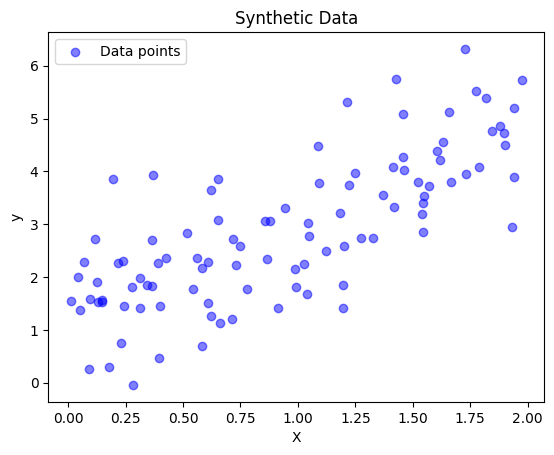

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

# Parameters for the true linear relationship
true_w = 2.0
true_b = 1.0

# Generate synthetic data
n_samples = 100
X = 2 * np.random.rand(n_samples, 1)  # Feature values between 0 and 2
noise = np.random.randn(n_samples, 1)  # Gaussian noise
y = true_w * X + true_b + noise  # Linear relationship with noise

# Plot the synthetic data
plt.scatter(X, y, color='blue', alpha=0.5, label='Data points')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Synthetic Data')
plt.legend()
plt.show()

In [7]:
# Initialize parameters
w_bgd = 0.0
b_bgd = 0.0

# Hyperparameters
learning_rate = 0.01
n_iterations = 100

# To store the loss values
loss_history_bgd = []

# Batch Gradient Descent
for i in range(n_iterations):
    # Predictions
    y_pred = w_bgd * X + b_bgd
    
    # Compute gradients
    error = y_pred - y
    dw = (2 / n_samples) * np.sum(error * X)
    db = (2 / n_samples) * np.sum(error)
    
    # Update parameters
    w_bgd -= learning_rate * dw
    b_bgd -= learning_rate * db
    
    # Compute and store the loss (Mean Squared Error)
    mse = np.mean(error ** 2)
    loss_history_bgd.append(mse)
    
    # Optional: Print loss every 10 iterations
    if (i + 1) % 10 == 0:
        print(f'BGD Iteration {i+1}/{n_iterations}, Loss: {mse:.4f}')

BGD Iteration 10/100, Loss: 5.2072
BGD Iteration 20/100, Loss: 2.7051
BGD Iteration 30/100, Loss: 1.6284
BGD Iteration 40/100, Loss: 1.1649
BGD Iteration 50/100, Loss: 0.9652
BGD Iteration 60/100, Loss: 0.8790
BGD Iteration 70/100, Loss: 0.8416
BGD Iteration 80/100, Loss: 0.8253
BGD Iteration 90/100, Loss: 0.8180
BGD Iteration 100/100, Loss: 0.8147
